# Rational Quadratic Fractal Interpolation Function (RQFIF)

We are given interpolation data

$$
\{(x_i,y_i)\}_{i=1}^{n}
$$

with

$$
x_1 < x_2 < \cdots < x_n
$$

together with:

- scaling factors

$$
\alpha_i
$$

- shape parameters

$$
r_i
$$

for

$$
i=1,2,\dots,n-1
$$

The affine maps are

$$
w_i(x,y)
=
\begin{pmatrix}
u_i(x) \\
v_i(x,y)
\end{pmatrix}
$$

where

$$
u_i(x)=a_ix+b_i
$$

and

$$
v_i(x,y)=\alpha_i y + R_i(x)
$$

The rational function is

$$
R_i(x)
=
\frac{
A_{1i}(1-\theta)^2
+
A_{2i}\theta(1-\theta)
+
A_{3i}\theta^2
}{
1+(r_i-2)\theta(1-\theta)
}
$$

where

$$
\theta
=
\frac{x-x_1}{x_n-x_1}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1 : Input interpolation data

We input:

$$
(x_1,y_1), (x_2,y_2), \dots, (x_n,y_n)
$$

together with

$$
\alpha_i
\quad\text{and}\quad
r_i
$$

In [2]:
# Interpolation points
x = np.array([0, 1, 2, 3, 4], dtype=float)
y = np.array([0, 2, 1, 3, 0], dtype=float)

# Scaling factors
alpha = np.array([0.2, -0.3, 0.25, 0.4])

# Shape parameters
r = np.array([3, 2.5, 4, 3])

# Number of maps
N = len(x) - 1

# Step 2 : Compute interval lengths

Define

$$
h_i=x_{i+1}-x_i
$$

and slopes

$$
\Delta_i
=
\frac{
y_{i+1}-y_i
}{
h_i
}
$$

In [3]:
h = np.diff(x)

Delta = np.diff(y) / h

# Step 3 : Estimate derivative parameters

We estimate derivatives using the arithmetic mean method.

For interior nodes:

$$
d_i
=
\frac{
h_i\Delta_{i-1}
+
h_{i-1}\Delta_i
}{
h_i+h_{i-1}
}
$$

Endpoint derivatives are estimated separately.

In [4]:
d = np.zeros(N + 1)

# Left endpoint
d[0] = Delta[0]

# Right endpoint
d[-1] = Delta[-1]

# Interior derivatives
for i in range(1, N):

    d[i] = (h[i] * Delta[i - 1] + h[i - 1] * Delta[i]) / ( h[i] + h[i - 1])

# Step 4 : Compute affine coefficients

The horizontal map is

$$
u_i(x)=a_ix+b_i
$$

with

$$
a_i
=
\frac{
x_{i+1}-x_i
}{
x_n-x_1
}
$$

and

$$
b_i
=
\frac{
x_nx_i-x_1x_{i+1}
}{
x_n-x_1
}
$$

In [5]:
x1 = x[0]
xn = x[-1]

y1 = y[0]
yn = y[-1]

a = np.zeros(N)
b = np.zeros(N)

for i in range(N):

    a[i] = (x[i + 1] - x[i]) / (xn - x1)

    b[i] = (xn * x[i]- x1 * x[i + 1]) / (xn - x1)

# Step 5 : Compute coefficients in the rational function

The coefficients are

$$
A_{1i}
=
y_i-\alpha_i y_1
$$

$$
A_{3i}
=
y_{i+1}-\alpha_i y_n
$$

and

$$
A_{2i}
=
r_i y_i
+
h_i d_i
-
\alpha_i
\left(
r_i y_1
+
(x_n-x_1)d_1
\right)
$$

In [6]:
A1 = np.zeros(N)
A2 = np.zeros(N)
A3 = np.zeros(N)

for i in range(N):

    A1[i] = (y[i]- alpha[i] * y1)

    A3[i] = (y[i + 1]- alpha[i] * yn)

    A2[i] = (r[i] * y[i]+ h[i] * d[i]- alpha[i] * (r[i] * y1 + (xn - x1) * d[0]))

# Step 6 : Define the rational function

The rational part is

$$
R_i(x)
=
\frac{
A_{1i}(1-\theta)^2
+
A_{2i}\theta(1-\theta)
+
A_{3i}\theta^2
}{
1+(r_i-2)\theta(1-\theta)
}
$$

where

$$
\theta
=
\frac{x-x_1}{x_n-x_1}
$$

In [7]:
def R(i, x_value):

    theta = (x_value - x1) / (xn - x1)

    numerator = ( A1[i] * (1 - theta) ** 2 + A2[i] * theta * (1 - theta) + A3[i] * theta ** 2)

    denominator = (1 + (r[i] - 2) * theta * (1 - theta))

    return numerator / denominator

# Step 7 : Define the IFS maps

The transformations are

$$
w_i(x,y)
=
\begin{pmatrix}
u_i(x) \\
v_i(x,y)
\end{pmatrix}
$$

where

$$
v_i(x,y)
=
\alpha_i y + R_i(x)
$$

In [8]:
def w(i, point):

    x_current, y_current = point

    # Horizontal map
    new_x = (a[i] * x_current + b[i])

    # Vertical map
    new_y = (alpha[i] * y_current + R(i, x_current))

    return np.array([new_x, new_y])

# Step 8 : Random Iteration Algorithm

Generate points recursively:

$$
(X_{k+1},Y_{k+1})
=
w_{i_k}(X_k,Y_k)
$$

where

$$
i_k
\in
\{1,2,\dots,n-1\}
$$

is selected randomly at each iteration.

In [9]:
num_iterations = 200000

points = np.zeros((num_iterations, 2))

current_point = np.array([x1, y1])

for k in range(num_iterations):

    # Random map selection
    i = np.random.randint(0, N)

    # Apply map
    current_point = w(i, current_point)

    # Store point
    points[k] = current_point

# Step 9 : Plot the attractor

The generated point cloud approximates the graph of the Rational Quadratic Fractal Interpolation Function.

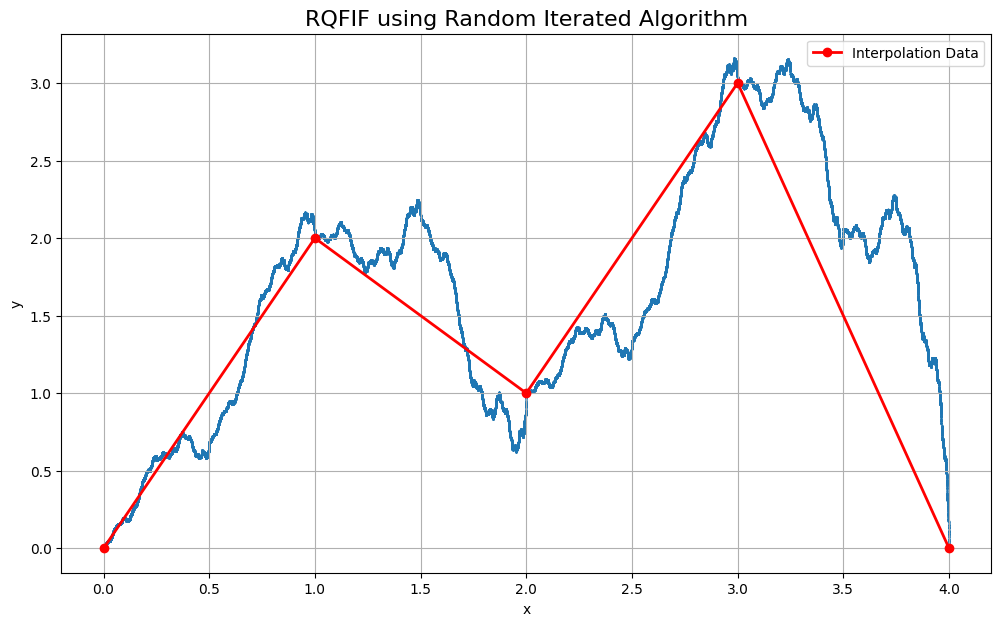

In [10]:
plt.figure(figsize=(12,7))

# Plot fractal points

plt.scatter(
    points[:,0],
    points[:,1],
    s=0.1
)
# plt.plot(
#     points[:,0],
#     points[:,1],
#     linewidth=0.7
# )

# Plot interpolation points
plt.plot(
    x,
    y,
    'ro-',
    linewidth=2,
    markersize=6,
    label='Interpolation Data'
)

plt.title(
    "RQFIF using Random Iterated Algorithm",
    fontsize=16
)

plt.xlabel("x")

plt.ylabel("y")

plt.grid(True)

plt.legend()

plt.show()

# Step 10 : Deterministic Algorithm

In the Random Iteration Algorithm, only one affine map is applied at each step.

In the deterministic approach, we apply **all maps to all current points**.

Mathematically,

$$
A_{k+1}
=
\bigcup_{i=1}^{n-1}
w_i(A_k)
$$

where

$$
A_k
$$

is the current approximation of the attractor.

As the number of iterations increases,

$$
A_k \to G(S)
$$

where

$$
G(S)
$$

is the graph of the Rational Quadratic Fractal Interpolation Function.

---

## Important Difference

### Random Iteration Algorithm

$$
(X_{k+1},Y_{k+1})
=
w_{i_k}(X_k,Y_k)
$$

Only one randomly selected map is applied.

---

### Deterministic Algorithm

$$
A_{k+1}
=
\bigcup_{i=1}^{n-1}
w_i(A_k)
$$

All affine maps are applied to all points.

In [11]:
# Initial approximation
current_points = np.column_stack((x, y))

# Number of deterministic iterations
deterministic_iterations = 7

# Step 11 : Apply deterministic iterations

At each iteration:

1. Take every current point
2. Apply every affine map
3. Collect all transformed points
4. Use them as the next approximation

The number of points grows exponentially:

$$
|A_k|
=
(n-1)^k |A_0|
$$

Therefore, the deterministic method becomes computationally expensive for large iteration counts.

In [12]:
for iteration in range(deterministic_iterations):

    new_points = []

    # Apply every map
    # to every current point

    for i in range(N):

        for point in current_points:

            transformed_point = w(i, point)

            new_points.append(transformed_point)

    current_points = np.array(new_points)

    print(
        f"Iteration {iteration+1} : "
        f"{len(current_points)} points"
    )

Iteration 1 : 20 points
Iteration 2 : 80 points
Iteration 3 : 320 points
Iteration 4 : 1280 points
Iteration 5 : 5120 points
Iteration 6 : 20480 points
Iteration 7 : 81920 points


# Step 12 : Plot deterministic attractor

The generated points approximate the graph of the Rational Quadratic Fractal Interpolation Function obtained using the deterministic method.

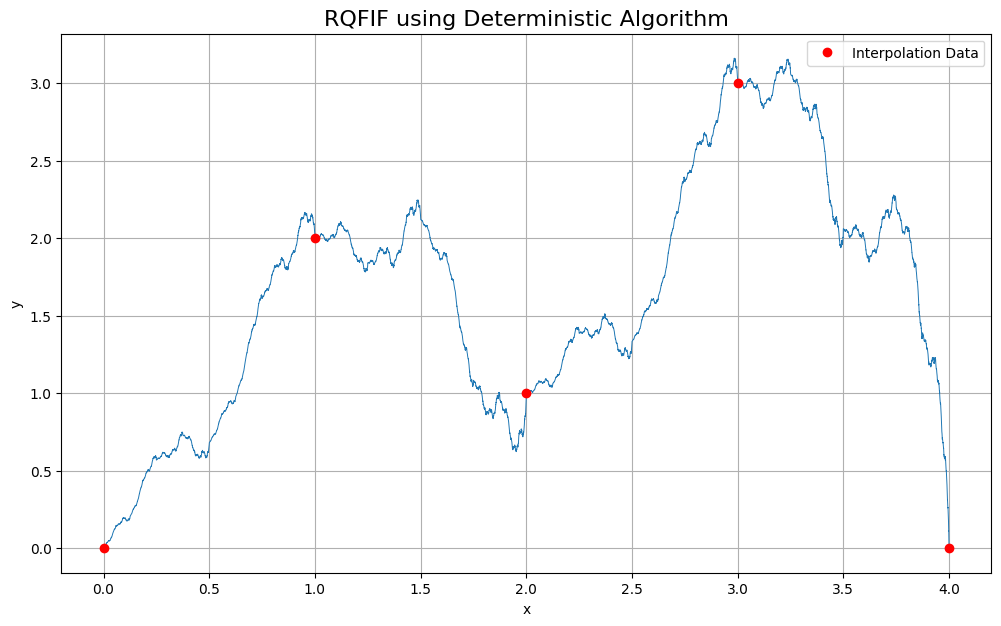

In [13]:
# Sort points for cleaner plotting

sorted_indices = np.argsort(current_points[:,0])

sorted_points = current_points[sorted_indices]

plt.figure(figsize=(12,7))

# Plot deterministic fractal curve
plt.plot(
    sorted_points[:,0],
    sorted_points[:,1],
    linewidth=0.7
)

# Plot interpolation data
plt.plot(
    x,
    y,
    'ro',
    markersize=6,
    label='Interpolation Data'
)

plt.title(
    "RQFIF using Deterministic Algorithm",
    fontsize=16
)

plt.xlabel("x")

plt.ylabel("y")

plt.grid(True)

plt.legend()

plt.show()